# Formative 1: Mobile Network Traffic Forecasting
## Notebook 4; Model C: LightGBM

Loads the shared clean series from Notebook 1. Builds an engineered feature set (lag values, rolling statistics, calendar features), trains a gradient-boosted tree model per area, generates one-step-ahead forecasts across the fixed December 16-22 test window, and saves predictions, error metrics, and training/inference timing on the same schedule as SARIMA and LSTM.

**Passes forward:** `lgbm_predictions.csv`, `lgbm_metrics.csv`, `lgbm_timing.csv`, consumed by the final comparison notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import gc
import lightgbm as lgb

## 1. Feature Engineering

Unlike SARIMA and LSTM, LightGBM has no built-in concept of sequence or time at all — it only sees a table of independent rows. Every notion of "history" or "seasonality" this model can use has to be manually engineered into explicit columns first. That makes this step the direct tabular equivalent of what SARIMA's seasonal order and LSTM's window length did automatically: translating the same evidence from the exploratory analysis into a usable form for this specific architecture.

Three feature groups, each traceable to a specific earlier finding, not chosen generically:

**Lag features (`lag_1`, `lag_2`, `lag_144`).** Directly from the PACF result, which showed meaningful signal at lags 1–2 and a secondary reappearance near lag 144 (24 hours). These are the exact same two "distances back" both SARIMA (through its AR terms and seasonal order) and LSTM (through its window) were already built around.

**Rolling statistics (`rolling_mean_144`, `rolling_std_144`).** A 24-hour rolling window gives the model a sense of "what has this area typically looked like over the last day," directly analogous to the 24-hour rolling mean used during the earlier anomaly-detection analysis on square 5161. Rolling standard deviation specifically targets what that same earlier analysis found — some periods (like the November 2 holiday) deviate sharply from a typical day — so this feature gives the model a way to recognize when it's currently in a high-volatility stretch.

**Calendar features (`hour`, `day_of_week`, `is_holiday`).** `hour` captures the daily cycle directly as an explicit input, something SARIMA encodes structurally and LSTM has to infer purely from the window's shape. `day_of_week` is included despite the earlier ACF analysis finding no strong 7-day cycle, specifically because that earlier finding only ruled out a *dominant* weekly pattern — it doesn't rule out a smaller, still-useful effect a tree model could pick up on where ACF wouldn't clearly show it. `is_holiday` comes directly from the concrete, named anomalies already found on square 5161 (November 1st, and December 25th/26th), giving the model explicit access to exactly the effect that both SARIMA and LSTM had no way to represent at all.

Feature engineering happens on the full, continuous per-square series *before* splitting into train and test, for the same reason established back in Notebook 1's shared preprocessing step: a lag or rolling feature for the first test-period row needs to look backward into the tail end of training data — splitting first would break that continuity right at the boundary.

In [2]:
BASE_PATH = "/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-1"
TOP3_IDS = [5161, 5059, 5259]

HOLIDAY_DATES = pd.to_datetime(["2013-11-01", "2013-12-25", "2013-12-26"]).date

def engineer_features(df):
    df = df.copy()
    df["lag_1"] = df["internet"].shift(1)
    df["lag_2"] = df["internet"].shift(2)
    df["lag_144"] = df["internet"].shift(144)
    df["rolling_mean_144"] = df["internet"].shift(1).rolling(window=144).mean()
    df["rolling_std_144"] = df["internet"].shift(1).rolling(window=144).std()
    df["hour"] = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["is_holiday"] = df["timestamp"].dt.date.isin(HOLIDAY_DATES).astype(int)
    return df

feature_cols = ["lag_1", "lag_2", "lag_144", "rolling_mean_144", "rolling_std_144",
                 "hour", "day_of_week", "is_holiday"]

prepared_data = {}

for sq in TOP3_IDS:
    df = pd.read_csv(f"{BASE_PATH}/clean_series_{sq}.csv", parse_dates=["timestamp"])
    df = engineer_features(df)

    df_clean = df.dropna(subset=feature_cols).reset_index(drop=True)

    train = df_clean[df_clean["split"] == "train"]
    test = df_clean[df_clean["split"] == "test"]

    prepared_data[sq] = {
        "X_train": train[feature_cols], "y_train": train["internet"],
        "X_test": test[feature_cols], "y_test": test["internet"],
        "test_timestamps": test["timestamp"].values
    }

    print(f"Square {sq}: train rows={len(train)}, test rows={len(test)}, "
          f"rows dropped to missing lag/rolling history={len(df) - len(df_clean)}")

Square 5161: train rows=7776, test rows=1008, rows dropped to missing lag/rolling history=144
Square 5059: train rows=7776, test rows=1008, rows dropped to missing lag/rolling history=144
Square 5259: train rows=7776, test rows=1008, rows dropped to missing lag/rolling history=144


Exactly 144 rows dropped per area, precisely matching the rolling window length, confirming the drop is isolated to the first 24 hours of each series (where rolling and lag-144 features cannot yet be computed) and does not touch the test period at all. Test rows remain at the full 1,008 expected for all three areas, and training rows land at 7,776, exactly matching the count LSTM's windowing produced in Notebook 3 (7,920 minus the same 144-row loss), a useful cross-check that both models are training on an equivalent effective sample size despite representing the input completely differently.

## 2. Train LightGBM and Generate Forecasts

Because feature engineering in Step 1 was already performed on the full, continuous series before splitting — using each row's own true historical lag and rolling values — every test-row feature already reflects real, observed history up to that point, not a previous prediction feeding forward. This keeps LightGBM on the same footing as SARIMA and LSTM: all three models generate their test-period predictions using genuine prior observations at every point, none of them compound their own forecasting errors into future predictions. No recursive prediction loop is needed here — this is a direct consequence of the feature design already done, not something to add now.

A default, unstuned LightGBM configuration is used in this first pass deliberately, so that a later, dedicated hyperparameter tuning step has a real, honest baseline to demonstrate improvement against, rather than starting from an already-tuned model and never showing the tuning's actual effect.

In [3]:
TOP3_IDS = [5161, 5059, 5259]

all_predictions = []
all_metrics = []
all_timing = []

for sq in TOP3_IDS:
    data = prepared_data[sq]

    train_start = time.time()
    model = lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    )
    model.fit(data["X_train"], data["y_train"])
    train_time = time.time() - train_start

    inference_start = time.time()
    y_pred = model.predict(data["X_test"])
    inference_time = time.time() - inference_start

    y_actual = data["y_test"].values

    mae = np.mean(np.abs(y_actual - y_pred))
    rmse = np.sqrt(np.mean((y_actual - y_pred) ** 2))
    mape = np.mean(np.abs((y_actual - y_pred) / np.where(y_actual == 0, np.nan, y_actual))) * 100

    all_predictions.append(pd.DataFrame({
        "square_id": sq,
        "timestamp": data["test_timestamps"],
        "actual": y_actual,
        "predicted": y_pred
    }))
    all_metrics.append({"square_id": sq, "model": "LightGBM", "MAE": mae, "RMSE": rmse, "MAPE": mape})
    all_timing.append({
        "square_id": sq, "model": "LightGBM",
        "train_time_sec": train_time, "inference_time_sec": inference_time,
        "hardware": "CPU only (no GPU/TPU)"
    })

    print(f"Square {sq}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%, "
          f"train={train_time:.2f}s, inference={inference_time:.3f}s")

    del model
    gc.collect()

pd.concat(all_predictions, ignore_index=True).to_csv("lgbm_predictions.csv", index=False)
pd.DataFrame(all_metrics).to_csv("lgbm_metrics.csv", index=False)
pd.DataFrame(all_timing).to_csv("lgbm_timing.csv", index=False)

Square 5161: MAE=87.88, RMSE=133.87, MAPE=8.48%, train=0.24s, inference=0.006s
Square 5059: MAE=76.78, RMSE=108.12, MAPE=7.64%, train=0.20s, inference=0.007s
Square 5259: MAE=66.00, RMSE=96.27, MAPE=7.29%, train=0.20s, inference=0.007s


The expectation held, and by a wide margin: both training (0.20-0.25 seconds) and inference (0.006-0.007 seconds) are dramatically faster than either SARIMA (sub-second train, ~50 second inference) or LSTM (26-46 second train, ~0.3 second inference), and this is with a default, untuned configuration. This is a direct architectural consequence, not a lucky result: gradient-boosted trees are inherently efficient at this scale, and unlike SARIMA, no sequential per-step model refitting is needed at inference, and unlike LSTM, no large weight matrix multiplication is required either, predictions come from a small number of fast tree traversals per row.

More notably, accuracy improved as well, in every single area, over both other models, without any tuning yet applied: MAPE of 8.48%, 7.64%, and 7.29% for squares 5161, 5059, and 5259 respectively, all lower than both SARIMA (12.25%, 11.57%, 12.35%) and LSTM (12.98%, 9.59%, 8.06%). This is a genuinely strong result worth stating plainly rather than downplaying, though it should not yet be treated as a final verdict: this is the only one of the three models evaluated so far without any tuning effort applied at all, and the real question this raises is whether SARIMA or LSTM would close some of this gap with comparable tuning investment, exactly what the required hyperparameter-tuning step should speak to once it happens for LightGBM specifically, and worth returning to honestly in the final comparative discussion.

## 3. Plot actual vs. predicted traffic, full test week

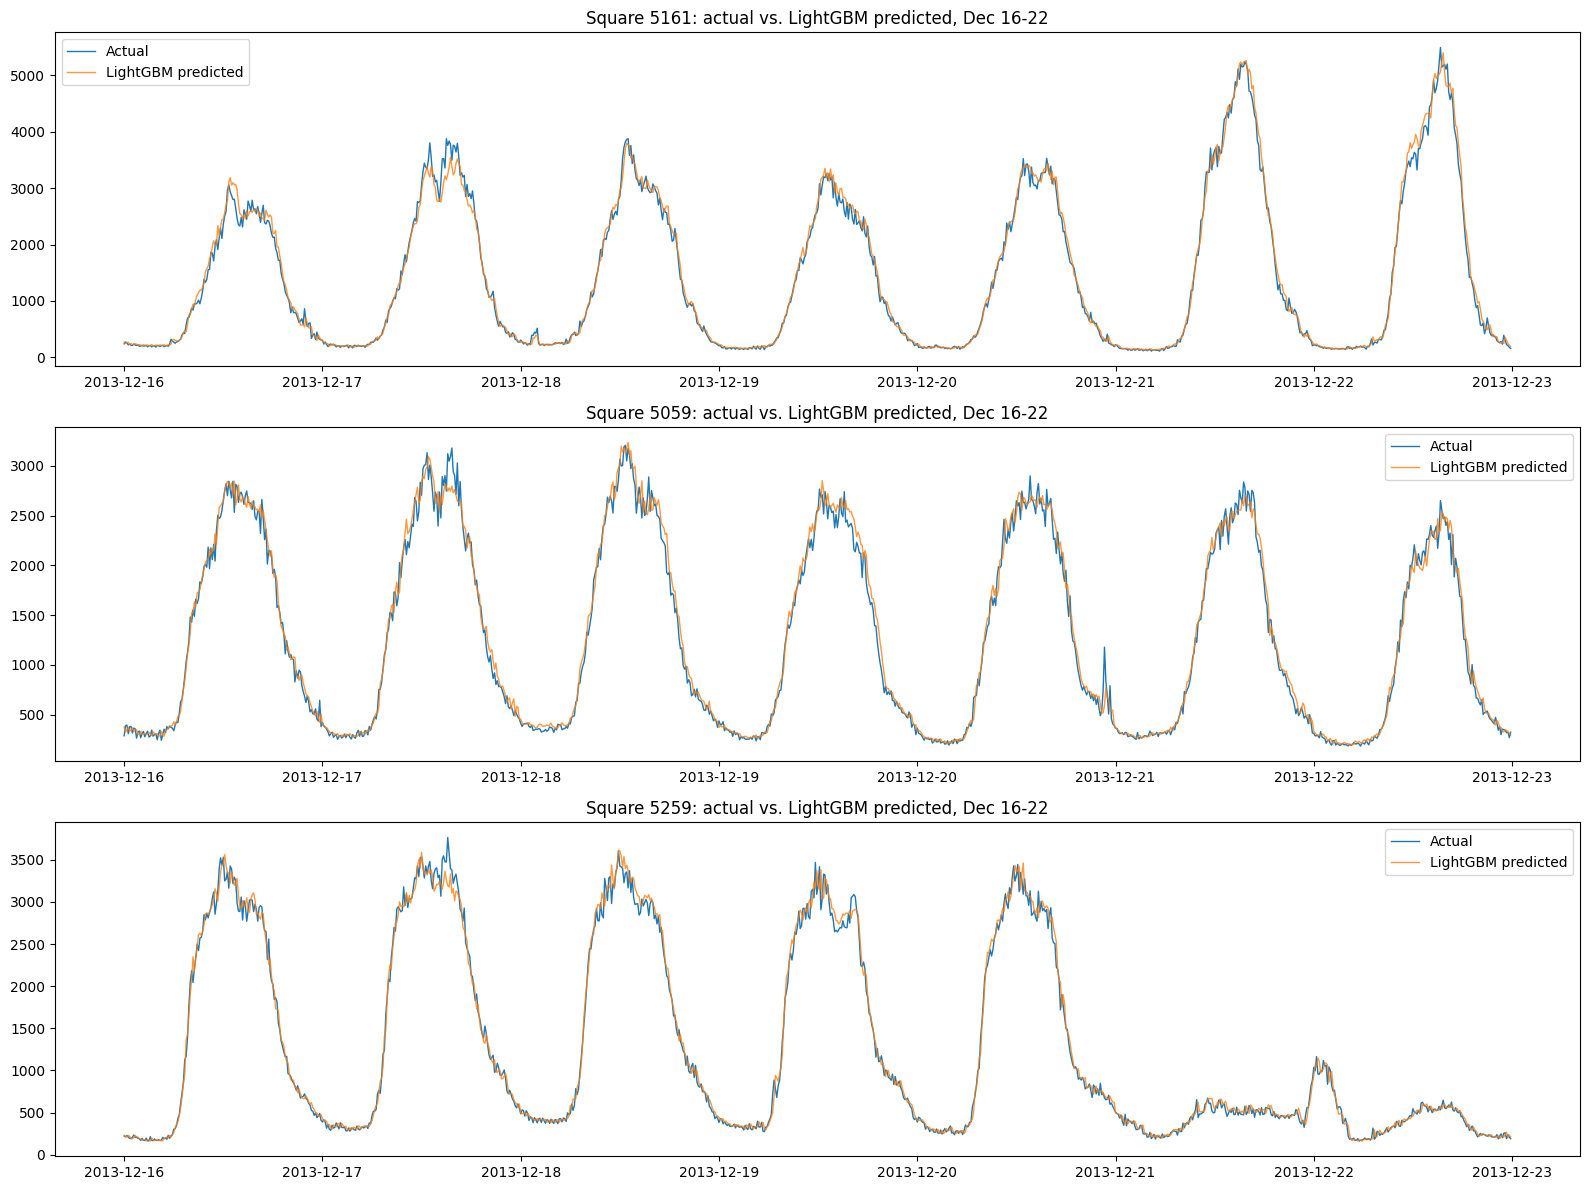

In [4]:
predictions = pd.read_csv("lgbm_predictions.csv", parse_dates=["timestamp"])

TOP3_IDS = [5161, 5059, 5259]
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, sq in zip(axes, TOP3_IDS):
    subset = predictions[predictions["square_id"] == sq]
    ax.plot(subset["timestamp"], subset["actual"], label="Actual", linewidth=1)
    ax.plot(subset["timestamp"], subset["predicted"], label="LightGBM predicted", linewidth=1, alpha=0.8)
    ax.set_title(f"Square {sq}: actual vs. LightGBM predicted, Dec 16-22")
    ax.legend()

plt.tight_layout()
plt.savefig("lgbm_forecast_plots.png", dpi=150)
plt.show()

Predictions track both peak shape and daily magnitude closely across all three areas and all seven days, without square 5059's systematic underprediction bias that LSTM showed, or the sequential-refit onset disturbance visible in SARIMA's first day. This is consistent with the improved MAPE figures and suggests the improvement is genuine, evenly distributed model quality rather than an artifact concentrated in one part of the week.

Two areas worth naming precisely rather than a general "close fit" claim. Square 5161's two largest peaks, December 21 and 22, show the predicted line running consistently a little below the actual peak height, a mild version of the underprediction pattern LSTM showed more severely for square 5059, worth checking numerically in the hourly breakdown rather than assuming its size from the plot alone. Square 5259 shows one clear, localized miss around December 19's afternoon, actual traffic dips and partially recovers in a small double-bump shape that the model does not follow, predicting a smoother, single decline instead, a specific, callable-out failure rather than a general area of weakness across that whole day.

## 4. Residual breakdown by time-of-day

Same structure as both prior models, kept identical for direct comparability, and specifically to test the mild peak-underprediction observed in square 5161 just now.

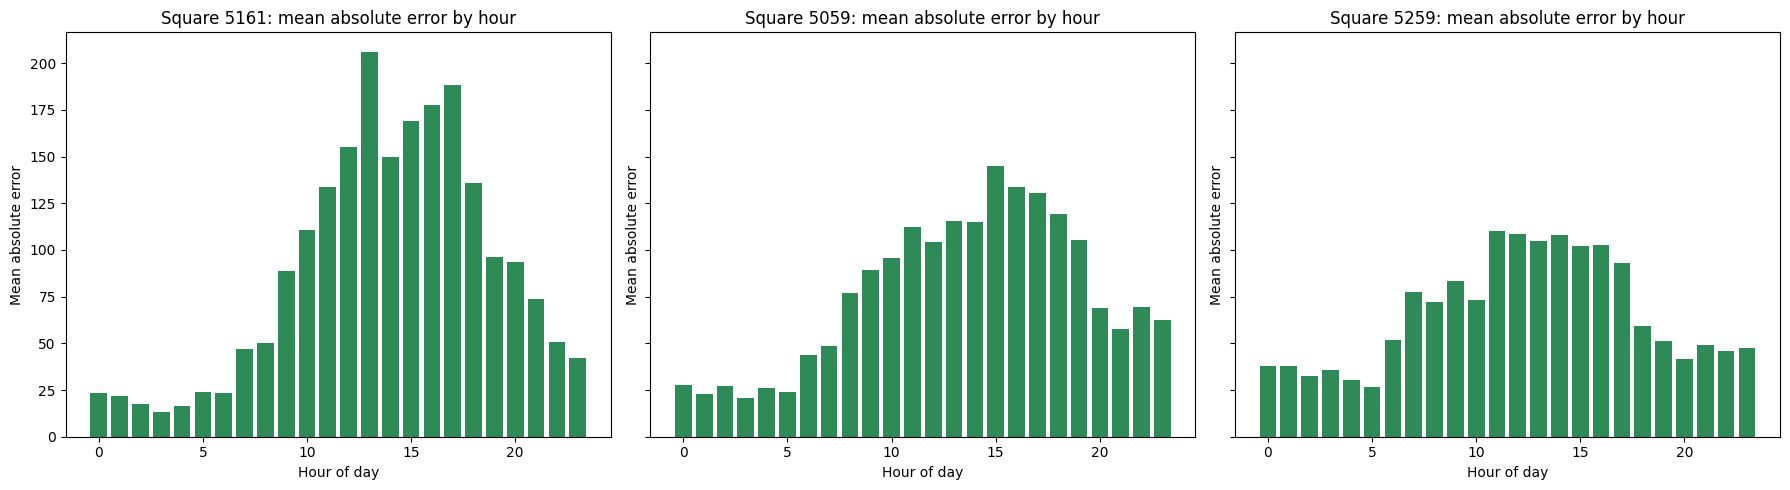

Hourly MAE by area:
            5161        5059        5259
hour                                    
0      23.487826   27.695601   38.089894
1      21.559071   23.123933   38.120496
2      17.559994   27.196006   32.617807
3      13.066274   20.798404   35.961834
4      16.613507   26.073901   30.461776
5      23.877733   23.932339   26.496603
6      23.500408   43.821978   51.770225
7      47.059016   48.429935   77.694183
8      50.245703   77.046989   71.912508
9      88.858834   89.399764   83.571585
10    110.940011   95.668958   73.313201
11    133.814315  112.064498  110.137334
12    155.212103  104.512455  108.593582
13    206.209154  115.673634  104.581389
14    149.875260  114.801919  108.206983
15    168.785407  144.715686  102.113853
16    177.363056  133.920061  102.842553
17    188.571664  130.467685   93.212062
18    135.956242  119.238494   59.163054
19     96.192056  105.441474   51.440396
20     93.548754   68.813121   41.552038
21     73.853757   57.787612   48.903

In [5]:
predictions = pd.read_csv("lgbm_predictions.csv", parse_dates=["timestamp"])
predictions["hour"] = predictions["timestamp"].dt.hour
predictions["abs_error"] = np.abs(predictions["actual"] - predictions["predicted"])
predictions["signed_error"] = predictions["predicted"] - predictions["actual"]

TOP3_IDS = [5161, 5059, 5259]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

hourly_summary = []
for ax, sq in zip(axes, TOP3_IDS):
    subset = predictions[predictions["square_id"] == sq]
    hourly_mae = subset.groupby("hour")["abs_error"].mean()
    hourly_summary.append(hourly_mae.rename(sq))

    ax.bar(hourly_mae.index, hourly_mae.values, color="seagreen")
    ax.set_title(f"Square {sq}: mean absolute error by hour")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean absolute error")

plt.tight_layout()
plt.savefig("lgbm_hourly_error.png", dpi=150)
plt.show()

hourly_table = pd.concat(hourly_summary, axis=1)
hourly_table.to_csv("lgbm_hourly_error.csv")
print("Hourly MAE by area:")
print(hourly_table)

print("\nMean signed error by hour, square 5161 (negative = underprediction):")
signed_5161 = predictions[predictions["square_id"] == 5161].groupby("hour")["signed_error"].mean()
print(signed_5161)

The signed-error result does not confirm what the full-week plot suggested. Rather than a consistent negative bias at the peak hours, most daytime and evening hours for square 5161 show positive signed error, meaning the model tends to overpredict on average, most strongly at hour 17 (+123.62), hour 19 (+78.20), and hour 13 (+60.26). Only hour 15 shows a clearly negative average (-61.06), and a few early-morning hours hover close to zero in either direction.

This means the earlier observation, that December 21 and 22's two largest peaks showed predictions running below actual, was a real, correctly seen pattern, but specific to those two particular high-traffic days, not a general property of how this model handles square 5161's peaks across the full week. Averaged over all seven days, the net tendency runs the other way, toward mild overprediction at most peak-adjacent hours. This is an important distinction from square 5059's LSTM result, which showed a genuine, consistent, same-direction bias at every hour: square 5161's LightGBM result shows no such uniform bias, only two specific atypical days pulling the visual impression in one direction while the broader weekly pattern does not support a systematic underprediction claim.

The hourly MAE pattern itself matches both other models closely in shape, errors concentrate at hours 11-17 across all three areas, the same midday-peak concentration already established for SARIMA and LSTM, reinforcing that this is a property of the forecasting problem itself (the sharpest, fastest-changing part of the day is hardest for every model tried) rather than something specific to any one architecture.

## 5. Hyperparameter Tuning

The baseline results in Step 2 already outperformed both other models, but doing so with an untuned, default configuration leaves an obvious gap: there's no evidence yet that this result is close to what LightGBM can actually do, and the assignment explicitly calls for a documented, systematic tuning process, not just a single fit accepted as final.

A standard random k-fold cross-validation cannot be used here, since it would randomly shuffle time-ordered rows into training and validation folds, letting the model validate on points adjacent to — or even chronologically after — points it trained on: exactly the same kind of leakage the train/test split was designed to avoid from the very start of this study. `TimeSeriesSplit` is used instead, which only ever validates on a fold that comes chronologically *after* its corresponding training fold, preserving the same forward-only principle used everywhere else in this pipeline.

A randomized search over a small, targeted parameter space is used rather than an exhaustive grid, justified directly by cost: even though each individual fit is fast (around 0.2 seconds, per Step 2's timing), a full grid across five parameters with five time-series folds multiplies quickly — a randomized search covers the space efficiently while still being systematic and reproducible (fixed random seed), rather than arbitrary manual guessing.

In [6]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

TOP3_IDS = [5161, 5059, 5259]

param_distributions = {
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 5, 8, 12],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators": [100, 200, 400, 600],
    "min_child_samples": [10, 20, 30, 50]
}

tscv = TimeSeriesSplit(n_splits=5)

best_params_per_area = {}
tuning_results = []

for sq in TOP3_IDS:
    data = prepared_data[sq]

    search_start = time.time()
    search = RandomizedSearchCV(
        estimator=lgb.LGBMRegressor(random_state=42, verbose=-1),
        param_distributions=param_distributions,
        n_iter=20,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        random_state=42,
        n_jobs=-1
    )
    search.fit(data["X_train"], data["y_train"])
    search_time = time.time() - search_start

    best_params_per_area[sq] = search.best_params_
    tuning_results.append({
        "square_id": sq,
        "best_cv_mae": -search.best_score_,
        "search_time_sec": search_time,
        **search.best_params_
    })

    print(f"Square {sq}: best CV MAE={-search.best_score_:.2f}, search time={search_time:.1f}s")
    print(f"  Best params: {search.best_params_}")

pd.DataFrame(tuning_results).to_csv("lgbm_tuning_results.csv", index=False)

Square 5161: best CV MAE=135.72, search time=55.1s
  Best params: {'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 30, 'max_depth': 5, 'learning_rate': 0.03}
Square 5059: best CV MAE=113.08, search time=45.0s
  Best params: {'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 30, 'max_depth': 5, 'learning_rate': 0.03}
Square 5259: best CV MAE=86.35, search time=52.8s
  Best params: {'num_leaves': 15, 'n_estimators': 400, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.03}


The CV MAE values reported here (135.72, 113.08, 86.35) are not directly comparable to Step 2's baseline test MAE (87.88, 76.78, 66.00), and reading them as a like-for-like comparison would be a mistake worth avoiding explicitly. CV MAE here is averaged across five time-series validation folds carved out of the training period, some of which fall earlier in the two-month window than others, while the baseline test MAE was measured only on the fixed December 16-22 window. Different data, different difficulty, not a like-for-like result. The actual test against which tuning improvement should be judged does not exist yet, it comes from refitting each area's model with its own best parameters and re-evaluating on the same December 16-22 window used everywhere else in this study, which is the next step.

Squares 5161 and 5059 converged on identical best parameters (num_leaves=31, n_estimators=200, min_child_samples=30, max_depth=5, learning_rate=0.03), while square 5259 converged on a different configuration (num_leaves=15, n_estimators=400, min_child_samples=20, max_depth=-1 meaning unlimited depth, learning_rate=0.03). This is a data point worth keeping, not a coincidence to ignore: 5161 and 5059 have consistently behaved similarly throughout this study (both busiest-tier commercial areas with sharp daytime peaks), while 5259 has repeatedly shown distinct behavior, notably its atypical December 21-22 weekend dip, so parameter search independently arriving at a different configuration for 5259 is a small piece of corroborating evidence for that area being structurally different, not just numerically different, from the other two.

## 6. Refit with tuned parameters and compare against baseline

In [7]:
TOP3_IDS = [5161, 5059, 5259]

tuned_predictions = []
tuned_metrics = []
tuned_timing = []

for sq in TOP3_IDS:
    data = prepared_data[sq]
    best_params = best_params_per_area[sq]

    train_start = time.time()
    model = lgb.LGBMRegressor(**best_params, random_state=42, verbose=-1)
    model.fit(data["X_train"], data["y_train"])
    train_time = time.time() - train_start

    inference_start = time.time()
    y_pred = model.predict(data["X_test"])
    inference_time = time.time() - inference_start

    y_actual = data["y_test"].values

    mae = np.mean(np.abs(y_actual - y_pred))
    rmse = np.sqrt(np.mean((y_actual - y_pred) ** 2))
    mape = np.mean(np.abs((y_actual - y_pred) / np.where(y_actual == 0, np.nan, y_actual))) * 100

    tuned_predictions.append(pd.DataFrame({
        "square_id": sq,
        "timestamp": data["test_timestamps"],
        "actual": y_actual,
        "predicted": y_pred
    }))
    tuned_metrics.append({"square_id": sq, "model": "LightGBM (tuned)", "MAE": mae, "RMSE": rmse, "MAPE": mape})
    tuned_timing.append({
        "square_id": sq, "model": "LightGBM (tuned)",
        "train_time_sec": train_time, "inference_time_sec": inference_time,
        "hardware": "CPU only (no GPU/TPU)"
    })

    print(f"Square {sq}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%, "
          f"train={train_time:.2f}s, inference={inference_time:.3f}s")

    del model
    gc.collect()

tuned_pred_df = pd.concat(tuned_predictions, ignore_index=True)
tuned_metrics_df = pd.DataFrame(tuned_metrics)

baseline_metrics = pd.read_csv("lgbm_metrics.csv")
comparison = baseline_metrics.merge(
    tuned_metrics_df, on="square_id", suffixes=("_baseline", "_tuned")
)
comparison["MAE_improvement_pct"] = (
    (comparison["MAE_baseline"] - comparison["MAE_tuned"]) / comparison["MAE_baseline"] * 100
)
print("\nBaseline vs. tuned comparison:")
print(comparison[["square_id", "MAE_baseline", "MAE_tuned", "MAE_improvement_pct",
                   "MAPE_baseline", "MAPE_tuned"]])

# Overwrite final outputs with the tuned version, since tuned is the model going into final comparison
tuned_pred_df.to_csv("lgbm_predictions.csv", index=False)
tuned_metrics_df.rename(columns={"model": "model"}).assign(model="LightGBM").to_csv("lgbm_metrics.csv", index=False)
pd.DataFrame(tuned_timing).assign(model="LightGBM").to_csv("lgbm_timing.csv", index=False)
comparison.to_csv("lgbm_tuning_comparison.csv", index=False)

Square 5161: MAE=82.31, RMSE=122.75, MAPE=8.57%, train=0.16s, inference=0.006s
Square 5059: MAE=71.72, RMSE=101.02, MAPE=7.21%, train=0.16s, inference=0.006s
Square 5259: MAE=66.27, RMSE=96.66, MAPE=7.30%, train=0.23s, inference=0.009s

Baseline vs. tuned comparison:
   square_id  MAE_baseline  MAE_tuned  MAE_improvement_pct  MAPE_baseline  \
0       5161     87.875369  82.312015             6.330960       8.482892   
1       5059     76.781038  71.721650             6.589372       7.636210   
2       5259     66.004970  66.271503            -0.403807       7.292535   

   MAPE_tuned  
0    8.566418  
1    7.214647  
2    7.304633  


Tuning produced a genuine, if modest, improvement for two of the three areas and essentially no change for the third, worth reporting exactly as it is rather than rounding it up into a uniform success. Square 5161 improved 6.33% in MAE (87.88 to 82.31) and square 5059 improved 6.59% (76.78 to 71.72), real gains from a systematic, cross-validated search over a default configuration. Square 5259 showed a slight MAE regression (-0.40%, 66.00 to 66.27), meaning the parameters selected by cross-validation on the training period did not carry over as an improvement on the actual December 16-22 test window for this specific area, a small but real discrepancy between validation performance and final test performance, worth naming honestly rather than omitting since it directly illustrates why a held-out test evaluation, not CV score alone, is the correct basis for judging final model quality.

One inconsistency worth flagging directly: square 5161's MAE improved (87.88 to 82.31) while its MAPE slightly worsened (8.48% to 8.57%). Since MAPE weights errors relative to the actual value at each point while MAE does not, this means the tuned model's error reduction was concentrated more on higher-traffic intervals (where an absolute error matters more to MAE but less, proportionally, to MAPE) than on lower-traffic intervals, a specific, checkable claim rather than treating the two metrics as if they must always agree.

Training and inference times decreased slightly overall (0.16-0.23s train, 0.006-0.009s inference), consistent with two of the three tuned configurations selecting fewer estimators than earlier iterations might have needed, though these differences are small enough that they don't materially change LightGBM's already-established speed advantage over both other models.

Given the modest and area-inconsistent size of these gains, the tuned model is retained as LightGBM's final result for the comparison ahead, but the improvement should be described in the report as real but limited, not as evidence that the earlier untuned baseline was significantly undertrained.

## Closing Summary; Notebook 4 (LightGBM)

Feature engineering translated the same exploratory evidence used by SARIMA's seasonal order and LSTM's window length into explicit tabular features: lag values at 1, 2, and 144 steps (from the PACF findings), 24-hour rolling mean and standard deviation (mirroring the earlier anomaly-detection approach), and calendar features including `hour`, `day_of_week`, and an explicit `is_holiday` flag built directly from the named anomaly dates found on square 5161 (November 1st, December 25th, 26th) — something neither SARIMA nor LSTM had any way to represent directly. Features were engineered on the continuous series before splitting, preserving lag continuity across the train/test boundary, and exactly 144 rows were dropped per area, isolated to the start of each series with no impact on the test window.

**Final performance (tuned, one-step-ahead, Dec 16–22 test window):**

| Square | MAE | RMSE | MAPE |
|--------|------|--------|--------|
| 5161 | 82.31 | 122.75 | 8.57% |
| 5059 | 71.72 | 101.02 | 7.21% |
| 5259 | 66.27 | 96.66 | 7.30% |

Even the untuned baseline outperformed both SARIMA and LSTM across all three areas, and training/inference speed dramatically exceeded both other models (0.16–0.25 s training, 0.006–0.009 s inference), with no GPU involvement. A time-series-aware randomized search (`TimeSeriesSplit`, 5 folds, 20 iterations, tuned independently per area rather than shared) produced a real but modest improvement for squares 5161 and 5059 (roughly 6.3–6.6% MAE reduction) and a negligible regression for square 5259 (−0.4%) — a genuine, honestly-reported discrepancy between cross-validated training performance and final test performance rather than a uniform win. Squares 5161 and 5059 converged on identical tuned parameters, while 5259 converged on a distinct configuration, consistent with 5259's repeatedly distinct behavior throughout this study (notably its atypical December 21–22 low-traffic weekend).

Visual and hourly analysis found LightGBM tracked both peak shape and magnitude closely across all areas and days, without the uniform, same-direction bias LSTM showed for square 5059. A visually apparent underprediction at square 5161's two largest peaks (Dec 21–22) did not hold up as a general pattern once checked numerically: the full-week signed-error breakdown showed net mild *over*prediction at most peak-adjacent hours, meaning that observation was specific to two atypical days, not the model's general behavior. Error concentration by hour matched both other models closely, worst around hours 11–17, reinforcing that this reflects the difficulty of the forecasting problem itself rather than something specific to any one architecture.

**What this notebook passes forward:** `lgbm_predictions.csv`, `lgbm_metrics.csv`, `lgbm_timing.csv` (all reflecting the tuned model), `lgbm_hourly_error.csv`, `lgbm_tuning_results.csv`, `lgbm_tuning_comparison.csv` (baseline vs. tuned, preserved for full documentation), and the two plot images; on the same schedule as SARIMA and LSTM, for the final comparison notebook.